In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge

from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
housing = fetch_california_housing(as_frame=True)

df = pd.concat(
    [housing.data,
     housing.target.rename("HousePrice")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("Shape:", df.shape)

df.info()

Shape: (20640, 9)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

In [6]:
X = df.drop("HousePrice", axis=1)

y = df["HousePrice"]

print(X.shape)
print(y.shape)

(20640, 8)
(20640,)


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

Training Samples : 16512
Testing Samples : 4128


In [9]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_pred)
)

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("RMSE :", lr_rmse)
print("R2 :", lr_r2)

Linear Regression
RMSE : 0.7455813830127764
R2 : 0.5757877060324508


In [10]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_pred)
)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression")
print("RMSE :", ridge_rmse)
print("R2 :", ridge_r2)

Ridge Regression
RMSE : 0.7455542909384607
R2 : 0.5758185345441325


In [11]:
tree = DecisionTreeRegressor(
    random_state=42
)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

tree_rmse = np.sqrt(
    mean_squared_error(y_test, tree_pred)
)

tree_r2 = r2_score(
    y_test,
    tree_pred
)

print("Decision Tree")
print("RMSE :", tree_rmse)
print("R2 :", tree_r2)

Decision Tree
RMSE : 0.7030445773467542
R2 : 0.6228111330554302


In [12]:
train_pred = tree.predict(X_train)

test_pred = tree.predict(X_test)

train_rmse = np.sqrt(
    mean_squared_error(y_train, train_pred)
)

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_pred)
)

print("Train RMSE :", train_rmse)
print("Test RMSE :", test_rmse)

Train RMSE : 3.218325866275131e-16
Test RMSE : 0.7030445773467542


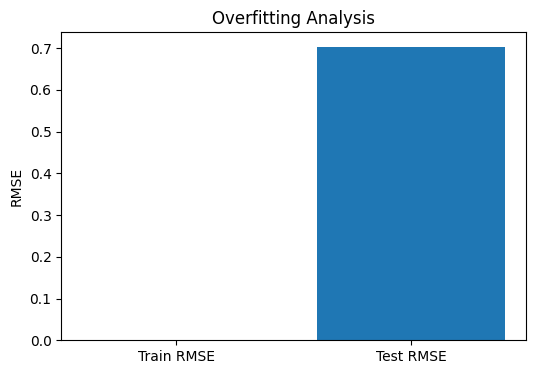

In [13]:
plt.figure(figsize=(6,4))

plt.bar(
    ["Train RMSE","Test RMSE"],
    [train_rmse,test_rmse]
)

plt.title("Overfitting Analysis")
plt.ylabel("RMSE")

plt.show()

In [14]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

cv_rmse_scores = -cv_scores

print("Cross Validation RMSE Scores")
print(cv_rmse_scores)

print("\nAverage CV RMSE")
print(cv_rmse_scores.mean())

Cross Validation RMSE Scores
[0.88767617 0.82781619 0.89845112 0.94507041 0.91950207]

Average CV RMSE
0.8957031908951016


In [15]:
param_grid = {
    "max_depth":[3,5,7,10],
    "min_samples_split":[2,5,10]
}

In [16]:
grid = GridSearchCV(
    estimator=DecisionTreeRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sco

In [17]:
print("Best Parameters")

print(grid.best_params_)

Best Parameters
{'max_depth': 10, 'min_samples_split': 10}


In [18]:
best_tree = grid.best_estimator_

best_pred = best_tree.predict(X_test)

best_rmse = np.sqrt(
    mean_squared_error(y_test,best_pred)
)

best_r2 = r2_score(
    y_test,
    best_pred
)

print("Optimized Decision Tree")

print("RMSE :", best_rmse)

print("R2 :", best_r2)

Optimized Decision Tree
RMSE : 0.6454300828015771
R2 : 0.6820992539714815


In [19]:
importance = best_tree.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
0,MedInc,0.614010
5,AveOccup,0.130288
6,Latitude,0.079659
7,Longitude,0.067425
1,HouseAge,0.044206
2,AveRooms,0.037286
4,Population,0.014889
3,AveBedrms,0.012237


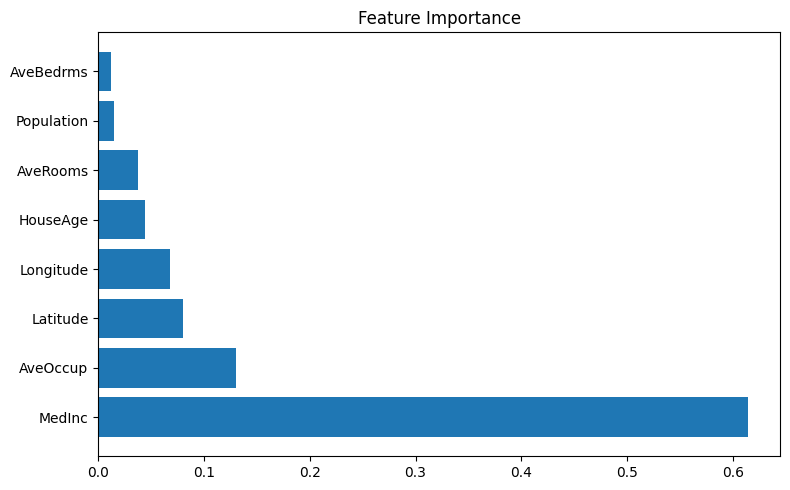

In [20]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [21]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree",
        "Optimized Decision Tree"
    ],
    "RMSE":[
        lr_rmse,
        ridge_rmse,
        tree_rmse,
        best_rmse
    ],
    "R2 Score":[
        lr_r2,
        ridge_r2,
        tree_r2,
        best_r2
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,RMSE,R2 Score
3,Optimized Decision Tree,0.645430,0.682099
2,Decision Tree,0.703045,0.622811
1,Ridge Regression,0.745554,0.575819
0,Linear Regression,0.745581,0.575788


In [22]:
print("""
Conclusion:

1. Linear Regression and Ridge Regression were used as baseline models.

2. Decision Tree initially showed overfitting due to a large gap between train and test performance.

3. Cross-validation provided a more reliable estimate of model performance.

4. GridSearchCV was used to tune hyperparameters and reduce overfitting.

5. The optimized Decision Tree achieved better generalization and was selected as the final model.
""")


Conclusion:

1. Linear Regression and Ridge Regression were used as baseline models.

2. Decision Tree initially showed overfitting due to a large gap between train and test performance.

3. Cross-validation provided a more reliable estimate of model performance.

4. GridSearchCV was used to tune hyperparameters and reduce overfitting.

5. The optimized Decision Tree achieved better generalization and was selected as the final model.

